In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/synthetic_fraud_dataset.csv")

print("Shape", df.shape)
df.head(10)

Shape (50000, 21)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1
5,TXN_42724,USER_6852,168.55,Online,2023-06-05 20:55:00,33236.94,Laptop,Tokyo,Restaurants,0,...,3,226.85,2,Discover,51,1725.64,OTP,0.0504,0,0
6,TXN_10822,USER_5052,3.79,POS,2023-11-07 01:18:00,86834.18,Tablet,London,Restaurants,0,...,2,298.35,2,Mastercard,168,3757.19,Password,0.0875,0,0
7,TXN_49498,USER_4660,7.08,ATM Withdrawal,2023-02-25 03:43:00,45826.27,Tablet,London,Restaurants,0,...,3,164.38,4,Discover,182,1764.66,Biometric,0.5326,0,1
8,TXN_4144,USER_1584,34.25,ATM Withdrawal,2023-03-09 22:51:00,94392.35,Tablet,Tokyo,Clothing,0,...,7,90.02,3,Visa,24,550.38,Biometric,0.1347,1,0
9,TXN_36958,USER_9498,16.24,POS,2023-09-20 17:27:00,91859.97,Mobile,Mumbai,Travel,0,...,6,474.42,1,Mastercard,124,720.91,PIN,0.3394,0,0


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,50000,50000,TXN_5311,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_ID,50000,8963,USER_6599,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction_Amount,50000.0,NaN,NaN,NaN,99.411012,98.687292,0.0,28.6775,69.66,138.8525,1174.14
Transaction_Type,50000,4,POS,12549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,50000,47724,2023-06-04 06:35:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account_Balance,50000.0,NaN,NaN,NaN,50294.065981,28760.458557,500.48,25355.995,50384.43,75115.135,99998.31
Device_Type,50000,3,Tablet,16779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,50000,5,Tokyo,10208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Merchant_Category,50000,5,Clothing,10033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP_Address_Flag,50000.0,NaN,NaN,NaN,0.0502,0.21836,0.0,0.0,0.0,0.0,1.0


In [6]:
print(df.columns.tolist())

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Timestamp', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 'Risk_Score', 'Is_Weekend', 'Fraud_Label']


In [7]:
TARGET = "Fraud_Label"

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [12]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


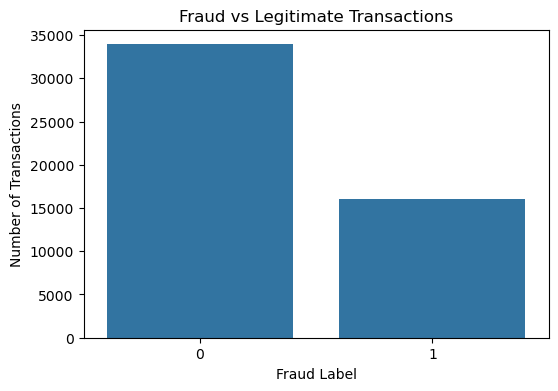

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Number of Transactions")
plt.show()